In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from google.colab import files
data = files.upload()

Saving advertising.csv to advertising.csv


In [8]:
df= pd.read_csv("advertising.csv")
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,27-03-2016 00:53,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,04-04-2016 01:39,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,13-03-2016 20:35,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,10-01-2016 02:31,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,03-06-2016 03:36,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [17]:
df.drop(['Ad Topic Line','City','Country','Timestamp'],axis=1,inplace=True)

In [18]:
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
0,68.95,35,61833.90,256.09,0,0
1,80.23,31,68441.85,193.77,1,0
2,69.47,26,59785.94,236.50,0,0
3,74.15,29,54806.18,245.89,1,0
4,68.37,35,73889.99,225.58,0,0


In [19]:
df['Male'].unique()

array([0, 1])

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Male                      1000 non-null   int64  
 5   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3)
memory usage: 47.0 KB


In [28]:
df.corr()*100

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
Daily Time Spent on Site,100.000000,-33.151334,31.095441,51.865848,-1.895085,-74.811656
Age,-33.151334,100.000000,-18.260496,-36.720856,-2.104406,49.253127
Area Income,31.095441,-18.260496,100.000000,33.749553,0.132236,-47.625463
Daily Internet Usage,51.865848,-36.720856,33.749553,100.000000,2.801233,-78.653918
Male,-1.895085,-2.104406,0.132236,2.801233,100.000000,-3.802747
Clicked on Ad,-74.811656,49.253127,-47.625463,-78.653918,-3.802747,100.000000


In [21]:
x= df[[
    "Daily Time Spent on Site",
    "Age",
    "Area Income",
    "Daily Internet Usage",
    "Male",
]]

In [22]:
y =df["Clicked on Ad"]

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [45]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [46]:
x_test.shape

(200, 5)

In [47]:
y_train.shape

(800,)

In [48]:
model = LogisticRegression()

In [49]:
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [50]:
y_pred=model.predict(x_test)

In [51]:
from sklearn.metrics import accuracy_score,confusion_matrix

In [59]:
accuracy_score(y_test,y_pred)

0.92

In [54]:
y_pred[0:5]

array([0, 0, 1, 0, 1])

In [56]:
y_test[0:5]

,Clicked on Ad
850,0
201,0
28,1
625,1
357,1


In [57]:
confusion_matrix(y_test,y_pred)

array([[ 81,  10],
       [  6, 103]])

In [58]:
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
0,68.95,35,61833.90,256.09,0,0
1,80.23,31,68441.85,193.77,1,0
2,69.47,26,59785.94,236.50,0,0
3,74.15,29,54806.18,245.89,1,0
4,68.37,35,73889.99,225.58,0,0


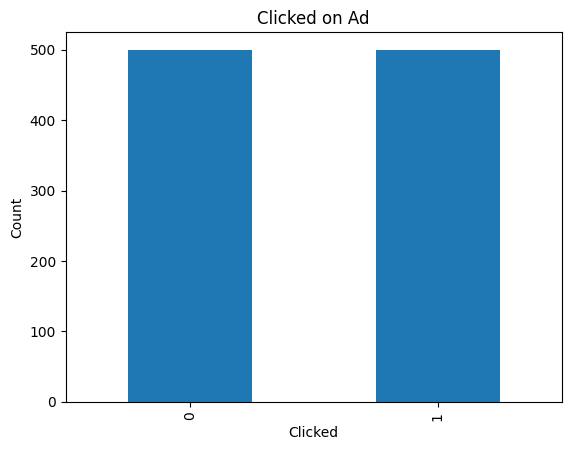

In [60]:
import matplotlib.pyplot as plt

df["Clicked on Ad"].value_counts().plot(kind="bar")

plt.title("Clicked on Ad")
plt.xlabel("Clicked")
plt.ylabel("Count")
plt.show()

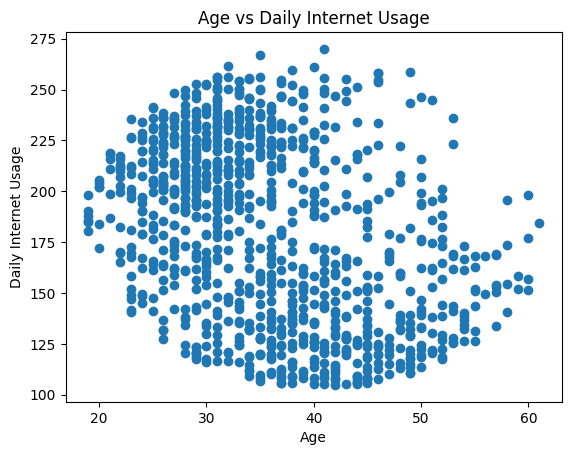

In [61]:
plt.scatter(df["Age"], df["Daily Internet Usage"])

plt.xlabel("Age")
plt.ylabel("Daily Internet Usage")
plt.title("Age vs Daily Internet Usage")
plt.show()

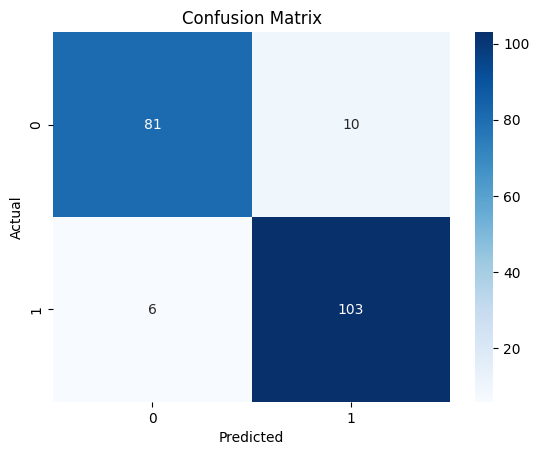

In [63]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

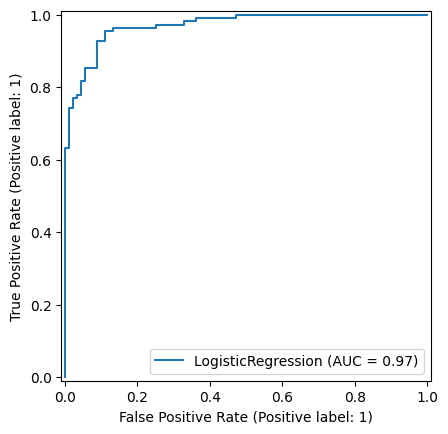

In [65]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model, x_test, y_test)

plt.show()